# submissionB.csv score distribution

`RS18B/submissionB.csv`의 `mislabel_score`, `dup_score`, `ood_score` 분포를 간단히 확인한다.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "Quest02":
    PROJECT_DIR = Path("/home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02")

SUBMISSION_PATH = PROJECT_DIR / "data" / "RS18B" / "submissionB.csv"

if not SUBMISSION_PATH.exists():
    raise FileNotFoundError(SUBMISSION_PATH)

print("SUBMISSION_PATH:", SUBMISSION_PATH)

SUBMISSION_PATH: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/data/RS18B/submissionB.csv


In [2]:
submission = pd.read_csv(SUBMISSION_PATH)
score_cols = ["mislabel_score", "dup_score", "ood_score"]
expected_cols = ["id", *score_cols]

print("shape:", submission.shape)
print("columns:", submission.columns.tolist())
display(submission.head())

if submission.columns.tolist() != expected_cols:
    raise ValueError(f"Unexpected columns: {submission.columns.tolist()}")

if submission[score_cols].isna().any().any():
    raise ValueError("NaN values found in score columns")

if not submission[score_cols].apply(lambda s: s.between(0, 1).all()).all():
    raise ValueError("Some scores are outside [0, 1]")

shape: (1366, 4)
columns: ['id', 'mislabel_score', 'dup_score', 'ood_score']


,id,mislabel_score,dup_score,ood_score
0,train_00000,0.000000,0.0,0.136164
1,train_00001,0.577361,0.0,0.241435
2,train_00002,0.000000,0.0,0.875695
3,train_00003,0.000000,0.0,0.352416
4,train_00004,0.000000,0.0,0.935286


In [3]:
summary = submission[score_cols].describe().T
summary["nonzero_count"] = (submission[score_cols] > 0).sum()
summary["zero_count"] = (submission[score_cols] == 0).sum()
summary["nonzero_ratio"] = summary["nonzero_count"] / len(submission)
display(summary)

,count,mean,std,min,25%,50%,75%,max,nonzero_count,zero_count,nonzero_ratio
mislabel_score,1366.0,0.030277,0.103918,0.000000,0.000000,0.000000,0.000000,0.974378,168,1198,0.122987
dup_score,1366.0,0.004279,0.041459,0.000000,0.000000,0.000000,0.000000,0.617583,28,1338,0.020498
ood_score,1366.0,0.499634,0.279747,0.008785,0.248682,0.502635,0.731296,0.999268,1366,0,1.000000


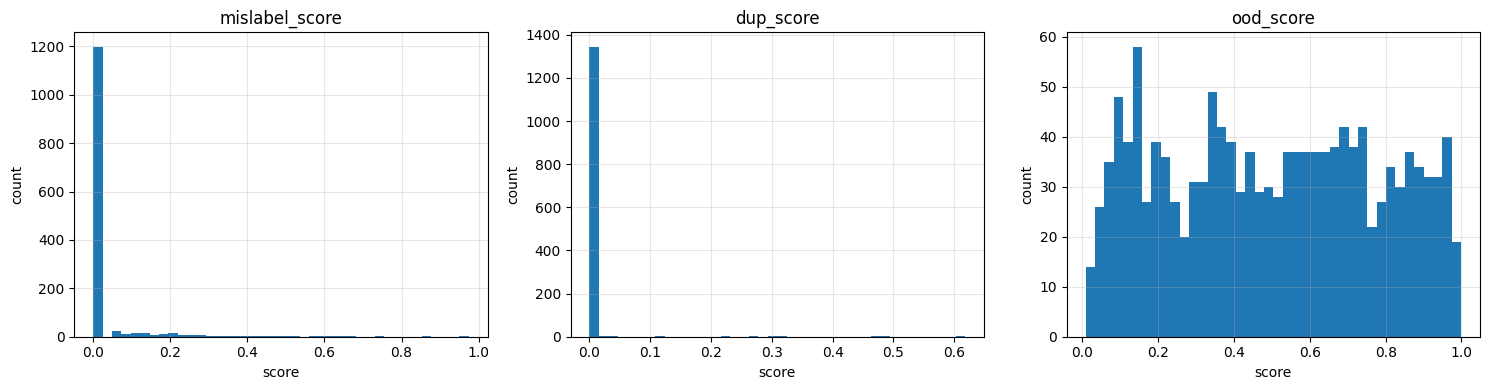

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, score_cols):
    ax.hist(submission[col], bins=40)
    ax.set_title(col)
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

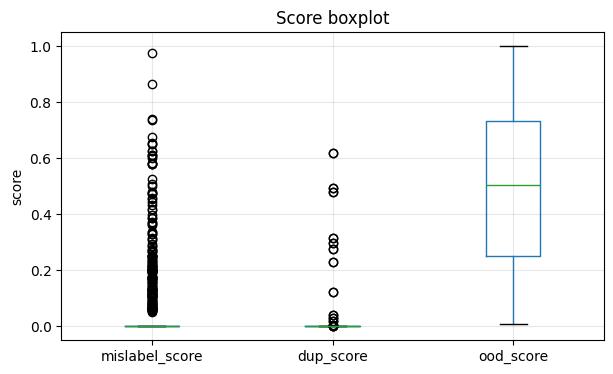

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
submission[score_cols].boxplot(ax=ax)
ax.set_title("Score boxplot")
ax.set_ylabel("score")
ax.grid(alpha=0.3)
plt.show()

In [6]:
for col in score_cols:
    print(f"\nTop 20 by {col}")
    display(submission.sort_values(col, ascending=False).head(20))


Top 20 by mislabel_score


,id,mislabel_score,dup_score,ood_score
742,train_00742,0.974378,0.0,0.086237
286,train_00286,0.863104,0.0,0.170864
979,train_00979,0.738133,0.0,0.046999
1000,train_01000,0.735923,0.0,0.049927
481,train_00481,0.673810,0.0,0.156515
926,train_00926,0.651991,0.0,0.185505
509,train_00509,0.650805,0.0,0.352123
99,train_00099,0.648513,0.0,0.134261
470,train_00470,0.623771,0.0,0.154466
1133,train_01133,0.623719,0.0,0.378917



Top 20 by dup_score


,id,mislabel_score,dup_score,ood_score
60,train_00060,0.000000,0.617583,0.910835
288,train_00288,0.000000,0.617583,0.913616
1343,train_01343,0.157007,0.491578,0.336164
126,train_00126,0.000000,0.491578,0.334407
1004,train_01004,0.000000,0.478036,0.046852
731,train_00731,0.000000,0.478036,0.033675
1098,train_01098,0.000000,0.314589,0.587701
1190,train_01190,0.000000,0.314589,0.582284
48,train_00048,0.000000,0.297556,0.665154
1135,train_01135,0.363743,0.297556,0.666471



Top 20 by ood_score


,id,mislabel_score,dup_score,ood_score
1208,train_01208,0.0,0.0,0.999268
127,train_00127,0.0,0.0,0.997365
1094,train_01094,0.0,0.0,0.996633
1283,train_01283,0.0,0.0,0.995315
1321,train_01321,0.0,0.0,0.995315
169,train_00169,0.0,0.0,0.993704
1301,train_01301,0.0,0.0,0.991654
9,train_00009,0.0,0.0,0.989751
737,train_00737,0.0,0.0,0.988433
358,train_00358,0.0,0.0,0.987701
